# Step 3-1 (A) : XGBoost Walk-Forward — Q, Ω 계산

> **목적**: ETF 22종 Long-Panel 데이터로 XGBoost 분류 모델을 Walk-Forward 방식으로 학습하고,
> Black-Litterman 입력값인 **Q** (기대수익률)와 **Ω** (뷰 불확실성)를 추출한다.

---

### Walk-Forward 구조 (Lopez de Prado, 2018)

```
│◀──── IS: 252일 ────▶│◀ Embargo: 21일 ▶│◀ OOS: 21일 ▶│  → 21일씩 슬라이딩
총 윈도우 수 ≈ (전체 날짜 - 252) / 21 ≈ 97개
```

### 출력 파일

| 파일 | 내용 |
|------|------|
| `outputs/step3/xgb_Q_Omega.parquet` | OOS 전체 Q, Ω, 확률, 실제수익률 |
| `outputs/step3/Q_xgb.parquet` | BL 입력용 Q 피벗 (date × ticker) |
| `outputs/step3/Omega_xgb.parquet` | BL 입력용 Ω 피벗 (date × ticker) |

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# ── 경로 설정 ──────────────────────────────────────────────────────────────────
DATA_DIR   = Path("data")
OUTPUT_DIR = Path("outputs/step3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Walk-Forward 파라미터 ──────────────────────────────────────────────────────
IS_DAYS         = 252   # 학습 구간 행 수 (≈ 1거래년, 연간 계절성 포착)
EMBARGO_DAYS    = 21    # IS-OOS 경계 엠바고 (Lopez de Prado)
OOS_DAYS        = 21    # 예측 구간 행 수
N_CLASSES       = 5     # 분류 등급: C1(강한하락) ~ C5(강한상승)
N_OPTUNA_TRIALS = 30    # Optuna 탐색 횟수 (속도 우선 시 10으로 줄여도 됨)
RANDOM_STATE    = 42

print("✅ 설정 완료")
print(f"  IS={IS_DAYS}일 | Embargo={EMBARGO_DAYS}일 | OOS={OOS_DAYS}일 | N_classes={N_CLASSES}")
print(f"  출력 경로: {OUTPUT_DIR.resolve()}")

✅ 설정 완료
  IS=252일 | Embargo=21일 | OOS=21일 | N_classes=5
  출력 경로: C:\workspace\camp\project\finance_project\서윤범\outputs\step3


## 2. 데이터 로드

Step2에서 저장된 `long_panel.parquet` 로드.  
Multi-Index: `[date, ticker]` / 타겟: `target_fwd` (21일 포워드 로그수익률)

In [2]:
# parquet 우선, 없으면 csv 시도
try:
    panel = pd.read_parquet(DATA_DIR / "long_panel.parquet")
    print("✅ parquet 로드 성공")
except FileNotFoundError:
    panel = pd.read_csv(DATA_DIR / "df_panel.csv", parse_dates=["Date"])
    panel = panel.rename(columns={"Date": "date", "Ticker": "ticker"})
    panel = panel.set_index(["date", "ticker"])
    print("✅ csv 로드 성공")

panel = panel.sort_index()

print(f"\nPanel shape : {panel.shape}")
print(f"날짜 범위   : {panel.index.get_level_values('date').min().date()} "
      f"~ {panel.index.get_level_values('date').max().date()}")
print(f"ETF 수      : {panel.index.get_level_values('ticker').nunique()}")
print(f"고유 날짜 수: {panel.index.get_level_values('date').nunique()}")
print(f"\n컬럼 목록: {panel.columns.tolist()}")

✅ csv 로드 성공

Panel shape : (51612, 36)
날짜 범위   : 2017-01-04 ~ 2025-12-31
ETF 수      : 22
고유 날짜 수: 2346

컬럼 목록: ['asset_class', 'sub_class', 'price', 'ret', 'ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'vol_21d', 'vol_63d', 'vol_ratio', 'beta_60d', 'beta_120d', 'rate_corr_60d', 'rsi_14d', 'VIX_level', 'VIX_contango', 'VIX_slope_9d_3m', 'VIX_slope_3m_6m', 'SKEW_level', 'SKEW_zscore', 'Cu_Au_ratio', 'Cu_Au_ratio_chg', 'HY_spread', 'HY_spread_chg', 'yield_curve', 'yield_curve_inv', 'claims_4wma', 'claims_zscore', 'WEI_level', 'sahm_indicator', 'DGS10_chg5', 'fwd_ret_5d', 'fwd_ret_21d', 'fwd_ret_63d', 'fwd_label_21d']


In [3]:
# 결측치 현황
missing = panel.isnull().mean().sort_values(ascending=False)
print("결측치 비율 (> 0인 컬럼만):")
print(missing[missing > 0].to_string())

결측치 비율 (> 0인 컬럼만):
fwd_ret_63d      0.026854
fwd_ret_21d      0.008951
fwd_label_21d    0.008951
fwd_ret_5d       0.002131
rsi_14d          0.000116


## 3. 피처 / 타겟 정의

In [4]:
TARGET_COL = "fwd_ret_21d"  # Step2 산출물 컬럼명
SECTOR_COL = "asset_class"  # Step2 산출물 컬럼명 (equity / bond / alt / equity_sector)

# ── 자산별 피처 (모멘텀·변동성·베타·민감도) ──────────────────────────────────
ASSET_FEATURES = [
    "ret_1m", "ret_3m", "ret_6m", "ret_12m",
    "vol_21d", "vol_63d", "vol_ratio",
    "beta_60d", "beta_120d",
    "rate_corr_60d", "rsi_14d",
]

# ── 매크로 피처 17개 ──────────────────────────────────────────────────────────
MACRO_FEATURES = [
    "VIX_level", "VIX_contango", "VIX_slope_9d_3m", "VIX_slope_3m_6m",
    "SKEW_level", "SKEW_zscore",
    "Cu_Au_ratio", "Cu_Au_ratio_chg",
    "HY_spread", "HY_spread_chg",
    "yield_curve", "yield_curve_inv",
    "claims_4wma", "claims_zscore",
    "WEI_level", "sahm_indicator",
    "DGS10_chg5",
]

# ── GDELT 감성 피처 (수집 완료 후 자동 추가) ──────────────────────────────────
GDELT_FEATURES = [
    "gdelt_avg_tone_1m", "gdelt_tone_momentum", "gdelt_article_volume",
]

# ── HMM 레짐 확률 (Step2에 추가되면 자동 추가) ────────────────────────────────
HMM_FEATURES = ["hmm_crisis_prob"]

# ── 수치형 전체 (SECTOR_COL 제외) ────────────────────────────────────────────
NUM_FEATURES = ASSET_FEATURES + MACRO_FEATURES + GDELT_FEATURES + HMM_FEATURES
ALL_FEATURES = NUM_FEATURES + [SECTOR_COL]

# ── 실제 존재하는 컬럼만 사용 (GDELT/HMM 수집 전 graceful 처리) ──────────────
available_num = [c for c in NUM_FEATURES if c in panel.columns]
available_cat = [SECTOR_COL] if SECTOR_COL in panel.columns else []
FINAL_FEATURES = available_num + available_cat

missing_cols = [c for c in ALL_FEATURES if c not in panel.columns]

print(f"수치형 피처: {len(available_num)}개")
print(f"카테고리 피처: {len(available_cat)}개  →  {available_cat}")
print(f"총 피처: {len(FINAL_FEATURES)}개")
if missing_cols:
    print(f"\n⚠️  아직 없는 피처 (수집 후 자동 추가됨): {missing_cols}")

수치형 피처: 28개
카테고리 피처: 1개  →  ['asset_class']
총 피처: 29개

⚠️  아직 없는 피처 (수집 후 자동 추가됨): ['gdelt_avg_tone_1m', 'gdelt_tone_momentum', 'gdelt_article_volume', 'hmm_crisis_prob']


## 4. Walk-Forward 날짜 윈도우 생성

**슬라이딩 방식**: IS 시작점을 OOS_DAYS씩 이동

```
Window 0:  IS[0:252]   →  Embargo[252:273]  →  OOS[273:294]
Window 1:  IS[21:273]  →  Embargo[273:294]  →  OOS[294:315]
...
```

> 💡 패널이 **월별** 주기라면 `IS_DAYS=7, EMBARGO_DAYS=1, OOS_DAYS=1` 로 재설정하세요.

In [5]:
dates_arr = (panel.index
            .get_level_values("date")
            .unique()
            .sort_values()
            .to_numpy())
n_dates = len(dates_arr)

windows = []
i = 0
while True:
    oos_end = i + IS_DAYS + EMBARGO_DAYS + OOS_DAYS
    if oos_end > n_dates:
        break
    windows.append({
        "window_id"     : len(windows),
        "is_dates"      : dates_arr[i : i + IS_DAYS],
        "emb_dates"     : dates_arr[i + IS_DAYS : i + IS_DAYS + EMBARGO_DAYS],
        "oos_dates"     : dates_arr[i + IS_DAYS + EMBARGO_DAYS : oos_end],
        "oos_start_date": dates_arr[i + IS_DAYS + EMBARGO_DAYS],
        "oos_end_date"  : dates_arr[oos_end - 1],
    })
    i += OOS_DAYS  # 슬라이딩

print(f"총 날짜 수  : {n_dates}")
print(f"총 윈도우 수: {len(windows)}")
print("\n[윈도우 샘플]")
for w in windows[:3]:
    print(f"  W{w['window_id']:02d}: IS {w['is_dates'][0]!s:.10s}~{w['is_dates'][-1]!s:.10s} "
          f"| OOS {w['oos_start_date']!s:.10s}~{w['oos_end_date']!s:.10s}")
print("  ...")

총 날짜 수  : 2346
총 윈도우 수: 98

[윈도우 샘플]
  W00: IS 2017-01-04~2017-12-21 | OOS 2018-01-22~2018-02-19
  W01: IS 2017-02-02~2018-01-19 | OOS 2018-02-20~2018-03-20
  W02: IS 2017-03-03~2018-02-19 | OOS 2018-03-21~2018-04-18
  ...


## 5. 핵심 헬퍼 함수

In [6]:
def discretize_labels(is_ret, oos_ret, n_classes=5):
    """
    IS 수익률 분위수로 bins 계산 -> IS.OOS 레이블 반환
    bins는 IS 데이터만으로 결정 (look-ahead bias 완전 차단)
    """
    _, bins = pd.qcut(is_ret, q=n_classes, retbins=True, duplicates="drop")
    bins[0]  = -np.inf
    bins[-1] =  np.inf

    def _cut(arr):
        # pd.cut -> Categorical -> pd.Series 경유해야 .fillna() 사용 가능
        # (최신 pandas에서 Categorical.astype(float)이 numpy array를 반환하므로)
        return (pd.Series(
                    pd.cut(arr, bins=bins,
                           labels=list(range(n_classes)),
                           include_lowest=True)
                ).astype(float).fillna(0).astype(int).values)

    is_labels  = _cut(is_ret)
    oos_labels = _cut(oos_ret)

    r_bar = {k: float(is_ret[is_labels == k].mean())
             if (is_labels == k).sum() > 0 else 0.0
             for k in range(n_classes)}

    return is_labels, oos_labels, bins, r_bar


def compute_Q_Omega(proba, r_bar, n_classes=5):
    """
    Q_i  = sum_k  r_k * P(C_k | z_i)
    Omega_ii = sum_k  P(C_k | z_i) * (r_k - Q_i)^2
    """
    r_arr = np.array([r_bar[k] for k in range(n_classes)])
    Q     = proba @ r_arr
    Omega = np.sum(
        proba * (r_arr[np.newaxis, :] - Q[:, np.newaxis])**2,
        axis=1
    )
    return Q, Omega


def build_X(df, num_cols, cat_col=None):
    """
    feature DataFrame 구성.
    cat_col이 있으면 category dtype으로 추가 -> XGBoost enable_categorical=True 전달용.
    """
    X = df[num_cols].fillna(0).copy()
    if cat_col and cat_col in df.columns:
        X[cat_col] = df[cat_col].astype('category')
    return X


def r2_oos(y_true, y_pred):
    """OOS R^2 = 1 - SS_res/SS_tot"""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else np.nan


print("helper functions defined")

helper functions defined


## 6. Optuna 하이퍼파라미터 탐색 함수

In [9]:
def make_objective(X_tr, y_tr, n_classes, val_ratio=0.2, embargo_days=21):
    """
    Optuna objective 팩토리.
    IS를 80/20 시간 순 분할 → log_loss 최소화.

    embargo_days: 내부 Train/Val 경계에 적용하는 엠바고.
      IS 끝부분 레이블(fwd_ret_21d)이 OOS 가격을 참조하는 label overlap 방지.
      Train은 split 기준 앞 (80% - embargo_days)행, Val은 뒤 20%행.

    IS=252 기준:
      내부 Train: 252 × 0.8 - 21 = 180일 × 22 ETF ≈ 3,960행
      내부 Val:   252 × 0.2      =  50일 × 22 ETF ≈ 1,100행
    """
    split = int(len(X_tr) * (1 - val_ratio))
    train_end = max(split - embargo_days, 1)   # 음수 방지

    X_t = X_tr.iloc[:train_end]
    X_v = X_tr.iloc[split:]
    y_t, y_v = y_tr[:train_end], y_tr[split:]

    def objective(trial):
        params = dict(
            n_estimators       = trial.suggest_int("n_estimators", 100, 500),
            max_depth          = trial.suggest_int("max_depth", 3, 7),
            learning_rate      = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            subsample          = trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree   = trial.suggest_float("colsample_bytree", 0.5, 1.0),
            min_child_weight   = trial.suggest_int("min_child_weight", 1, 10),
            gamma              = trial.suggest_float("gamma", 0.0, 3.0),
            reg_lambda         = trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
            reg_alpha          = trial.suggest_float("reg_alpha", 1e-5, 1.0, log=True),
            # 고정값
            objective          = "multi:softprob",
            num_class          = n_classes,
            eval_metric        = "mlogloss",
            tree_method        = "hist",
            enable_categorical = True,
            random_state       = RANDOM_STATE,
            early_stopping_rounds=20,
            n_jobs             = -1,
            verbosity          = 0,
        )
        model = XGBClassifier(**params)
        model.fit(X_t, y_t,
                  eval_set=[(X_v, y_v)],
                  verbose=False)
        proba_v = model.predict_proba(X_v)
        return log_loss(y_v, proba_v)

    return objective


print("✅ Optuna objective 정의 완료")

✅ Optuna objective 정의 완료


## 7. Walk-Forward 메인 루프

각 윈도우마다:

1. **IS / OOS 분할** (엠바고 제외)
2. **5분위 이산화** → bins는 IS 기준, r̄_k 계산
3. **Optuna** 하이퍼파라미터 탐색 (IS 내부 80/20 시계열 분할)
4. **전체 IS**로 최종 XGBoost 학습
5. OOS 클래스 확률 예측 → **Q, Ω** 계산
6. Accuracy, R²_oos 기록


In [10]:
all_results    = []   # OOS 행별 예측 결과
window_stats   = []   # 윈도우별 성과 요약
best_params_log = []  # 윈도우별 최적 하이퍼파라미터
final_model    = None # 마지막 윈도우 모델 (피처 중요도용)

dates_level_idx = panel.index.get_level_values("date")

for window in tqdm(windows, desc="Walk-Forward"):
    wid = window["window_id"]

    # ── 1. IS / OOS 분할 ────────────────────────────────────────────────────
    # pd.DatetimeIndex로 변환 → Timestamp 타입 일치 보장 (numpy.datetime64 → Timestamp 해시 불일치 방지)
    is_dates_idx  = pd.DatetimeIndex(window["is_dates"])
    oos_dates_idx = pd.DatetimeIndex(window["oos_dates"])

    is_df  = panel[dates_level_idx.isin(is_dates_idx)].copy()
    oos_df = panel[dates_level_idx.isin(oos_dates_idx)].copy()

    is_df       = is_df.dropna(subset=[TARGET_COL])
    oos_pred_df = oos_df.dropna(subset=available_num)   # 피처 완전한 행
    oos_eval_df = oos_df.dropna(subset=[TARGET_COL])    # 실제값 있는 행

    if len(is_df) < IS_DAYS // 2 or len(oos_pred_df) == 0:
        continue

    # ── 2. 5분위 이산화 (IS 기준 bins) ──────────────────────────────────────
    is_ret       = is_df[TARGET_COL].values
    oos_ret_eval = oos_eval_df[TARGET_COL].values if len(oos_eval_df) > 0 else None
    dummy_oos    = np.zeros(len(oos_pred_df))

    try:
        is_labels, _, bins, r_bar = discretize_labels(
            is_ret, dummy_oos, n_classes=N_CLASSES
        )
    except Exception as e:
        print(f"  W{wid}: 이산화 실패 ({e}), 스킵")
        continue

    # ── 3. 피처 행렬 구성 (DataFrame 유지 → enable_categorical=True 지원) ────
    cat_col = available_cat[0] if available_cat else None
    X_is  = build_X(is_df, available_num, cat_col)
    X_oos = build_X(oos_pred_df, available_num, cat_col)
    y_is  = is_labels

    # ── 4. Optuna 탐색 ───────────────────────────────────────────────────────
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + wid),
    )
    study.optimize(
        make_objective(X_is, y_is, N_CLASSES),
        n_trials=N_OPTUNA_TRIALS,
        show_progress_bar=False,
    )

    best_p = study.best_params.copy()
    best_p.update({
        "objective"        : "multi:softprob",
        "num_class"        : N_CLASSES,
        "eval_metric"      : "mlogloss",
        "tree_method"      : "hist",
        "enable_categorical": True,
        "random_state"     : RANDOM_STATE,
        "n_jobs"           : -1,
        "verbosity"        : 0,
    })
    best_params_log.append({"window_id": wid, **best_p})

    # ── 5. 전체 IS로 최종 학습 ───────────────────────────────────────────────
    final_model = XGBClassifier(**best_p)
    final_model.fit(X_is, y_is, verbose=False)

    # ── 6. OOS 확률 예측 → Q, Ω ─────────────────────────────────────────────
    proba_oos = final_model.predict_proba(X_oos)   # (n_oos, 5)
    Q_arr, Omega_arr = compute_Q_Omega(proba_oos, r_bar, N_CLASSES)

    # ── 7. 평가 (실제값 있는 행에서만) ──────────────────────────────────────
    acc = r2 = np.nan
    if oos_ret_eval is not None and len(oos_eval_df) > 0:
        pred_idx = oos_pred_df.index
        eval_idx = oos_eval_df.index
        common   = pred_idx.intersection(eval_idx)
        if len(common) > 0:
            pred_pos_map = {idx: pos for pos, idx in enumerate(pred_idx)}
            eval_pos_map = {idx: pos for pos, idx in enumerate(eval_idx)}
            pred_pos = [pred_pos_map[i] for i in common]
            eval_pos = [eval_pos_map[i] for i in common]

            _, oos_labels_common, _, _ = discretize_labels(
                is_ret,
                oos_eval_df.iloc[eval_pos][TARGET_COL].values,
                n_classes=N_CLASSES
            )
            pred_classes = final_model.predict(X_oos.iloc[pred_pos])
            acc = accuracy_score(oos_labels_common, pred_classes)
            r2  = r2_oos(oos_eval_df.iloc[eval_pos][TARGET_COL].values,
                        Q_arr[pred_pos])

    # ── 8. 행별 결과 저장 ────────────────────────────────────────────────────
    eval_ret_map = {}
    if oos_ret_eval is not None:
        for i2, idx2 in enumerate(oos_eval_df.index):
            eval_ret_map[idx2] = oos_eval_df.iloc[i2][TARGET_COL]

    for i, idx in enumerate(oos_pred_df.index):
        row = {
            "date"      : idx[0],
            "ticker"    : idx[1],
            "Q"         : Q_arr[i],
            "Omega"     : Omega_arr[i],
            "actual_ret": eval_ret_map.get(idx, np.nan),
            "window_id" : wid,
        }
        for c in range(N_CLASSES):
            row[f"proba_C{c+1}"] = float(proba_oos[i, c])
        all_results.append(row)

    window_stats.append({
        "window_id"          : wid,
        "oos_start"          : window["oos_start_date"],
        "oos_end"            : window["oos_end_date"],
        "is_size"            : len(is_df),
        "oos_size"           : len(oos_pred_df),
        "oos_accuracy"       : acc,
        "oos_r2"             : r2,
        "optuna_best_logloss": study.best_value,
        "r_bar_C1"           : r_bar[0],
        "r_bar_C5"           : r_bar[4],
    })

print(f"✅ Walk-Forward 완료: {len(window_stats)}개 윈도우 처리")

Walk-Forward:   0%|          | 0/98 [00:00<?, ?it/s]

✅ Walk-Forward 완료: 98개 윈도우 처리


## 8. 결과 집계 및 저장

In [11]:
results_df = (pd.DataFrame(all_results)
            .set_index(["date", "ticker"])
            .sort_index())
stats_df   = pd.DataFrame(window_stats)
params_df  = pd.DataFrame(best_params_log)

results_df.to_parquet(OUTPUT_DIR / "xgb_Q_Omega.parquet")
stats_df.to_csv(OUTPUT_DIR / "xgb_window_stats.csv", index=False)
params_df.to_csv(OUTPUT_DIR / "xgb_best_params_log.csv", index=False)

print(f"xgb_Q_Omega.parquet     → shape {results_df.shape}")
print(f"xgb_window_stats.csv    → shape {stats_df.shape}")
print(f"xgb_best_params_log.csv → shape {params_df.shape}")

results_df.head(6)

xgb_Q_Omega.parquet     → shape (45274, 9)
xgb_window_stats.csv    → shape (98, 10)
xgb_best_params_log.csv → shape (98, 18)


Q     Omega  actual_ret  window_id  proba_C1  \
date       ticker                                                        
2018-01-22 AGG     0.004259  0.000039   -0.011258          0  0.003935   
           DBC     0.012598  0.000660   -0.017890          0  0.212873   
           EEM     0.001795  0.000412   -0.037558          0  0.300466   
           EFA     0.012808  0.000280   -0.051781          0  0.026591   
           GLD     0.005859  0.000411   -0.003243          0  0.225511   
           IWM     0.017467  0.000197   -0.047324          0  0.022796   

                   proba_C2  proba_C3  proba_C4  proba_C5  
date       ticker                                          
2018-01-22 AGG     0.507499  0.481166  0.004526  0.002874  
           DBC     0.073599  0.370037  0.092414  0.251077  
           EEM     0.083063  0.464169  0.100068  0.052234  
           EFA     0.242346  0.505210  0.087214  0.138639  
           GLD     0.049854  0.549163  0.092028  0.083443  
           IWM     0.051494  0.455130  0.375392  0.095187

## 9. 성과 요약 통계

In [12]:
print("=" * 55)
print("  XGBoost Walk-Forward OOS 성과 요약")
print("=" * 55)

acc_s = stats_df["oos_accuracy"].dropna()
r2_s  = stats_df["oos_r2"].dropna()

print(f"\n[5분위 분류 Accuracy]")
print(f"  평균   : {acc_s.mean():.4f}  (랜덤 기준선: {1/N_CLASSES:.4f})")
print(f"  중앙값 : {acc_s.median():.4f}")
print(f"  std    : {acc_s.std():.4f}")
print(f"  범위   : {acc_s.min():.4f} ~ {acc_s.max():.4f}")

print(f"\n[R²_oos  (Q vs 실제수익률)]")
print(f"  평균         : {r2_s.mean():.4f}")
print(f"  R²>0 비율    : {(r2_s>0).mean():.1%}  ← ML > Naive Mean인 윈도우 비율")
print(f"  범위         : {r2_s.min():.4f} ~ {r2_s.max():.4f}")

print(f"\n[Q / Ω 분포]")
print(f"  Q   평균: {results_df['Q'].mean():.5f}  std: {results_df['Q'].std():.5f}")
print(f"  Ω   평균: {results_df['Omega'].mean():.6f}  std: {results_df['Omega'].std():.6f}")

  XGBoost Walk-Forward OOS 성과 요약

[5분위 분류 Accuracy]
  평균   : 0.2757  (랜덤 기준선: 0.2000)
  중앙값 : 0.2662
  std    : 0.1196
  범위   : 0.0325 ~ 0.6429

[R²_oos  (Q vs 실제수익률)]
  평균         : -0.9579
  R²>0 비율    : 12.2%  ← ML > Naive Mean인 윈도우 비율
  범위         : -7.5383 ~ 0.3219

[Q / Ω 분포]
  Q   평균: 0.00195  std: 0.02521
  Ω   평균: 0.001450  std: 0.001437


## 9-1. Cross-Sectional IC (Information Coefficient)

R2_oos가 Q 절대값 정확도를 보는 반면, **IC는 같은 날짜에 Q 높은 ETF가 실제로 더 올랐는가 (상대 서열)**를 측정.
Black-Litterman에서 실질적으로 더 중요한 신호 품질 지표.

| 지표 | 의미 | 기준 |
|------|------|------|
| IC 평균 | Q 서열 vs 실제 수익률 서열의 평균 상관 | 0.05 이상이면 유의미 |
| ICIR | IC 평균 / IC 표준편차 (신호 일관성) | 0.5 이상이면 양호 |
| IC > 0 비율 | Q 서열이 맞은 날 비율 | 50% 이상이면 양호 |

  Cross-Sectional IC 분석
IC 평균  : -0.0446  (0.05 이상이면 유의미)
  IC std   : 0.3698
  ICIR     : -0.1207  (0.5 이상이면 양호, 1.0 이상이면 우수)
  IC > 0   : 44.4%  (50% 이상이면 양호)

  판정: 신호 없음 - 모델 재검토 필요


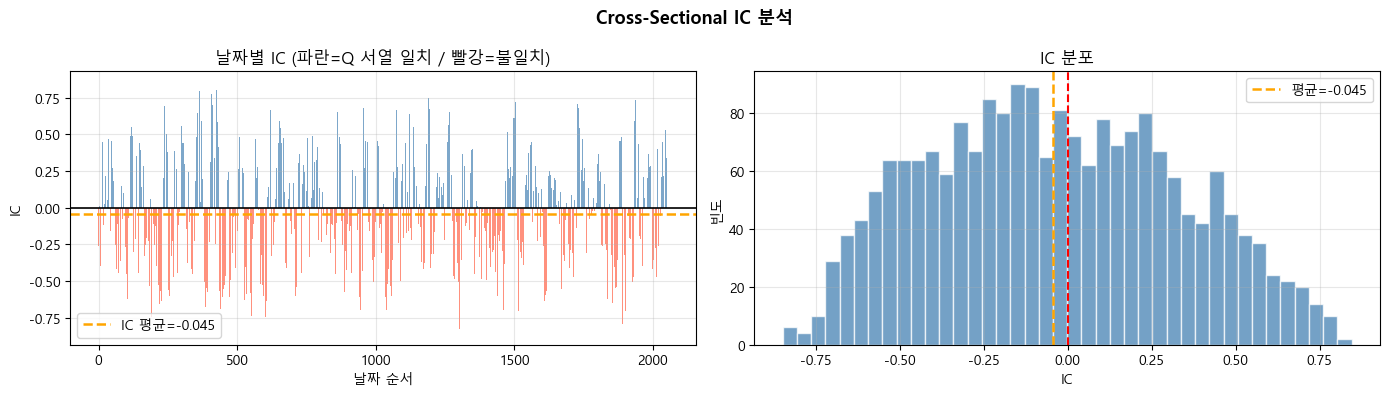

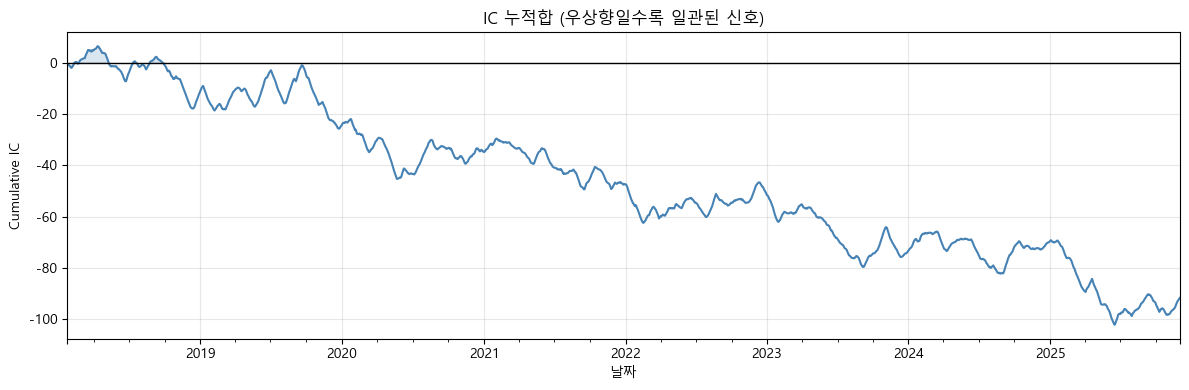

저장: outputs\step3


In [21]:
from scipy.stats import spearmanr

# ── 날짜별 크로스섹션 IC (Spearman) ──────────────────────────────────────────
def calc_ic(g):
    df = g.dropna(subset=["Q", "actual_ret"])
    if len(df) < 5:
        return np.nan
    return spearmanr(df["Q"], df["actual_ret"])[0]

ic_series = (
    results_df
    .groupby(level="date")
    .apply(calc_ic)
    .rename("IC")
    .dropna()
)

ic_mean = ic_series.mean()
ic_std  = ic_series.std()
icir    = ic_mean / ic_std if ic_std > 1e-12 else np.nan
ic_pos  = (ic_series > 0).mean()

print("=" * 50)
print("  Cross-Sectional IC 분석")
print("=" * 50)
print(f"IC 평균  : {ic_mean:.4f}  (0.05 이상이면 유의미)")
print(f"  IC std   : {ic_std:.4f}")
print(f"  ICIR     : {icir:.4f}  (0.5 이상이면 양호, 1.0 이상이면 우수)")
print(f"  IC > 0   : {ic_pos:.1%}  (50% 이상이면 양호)")
print()
if icir > 1.0:
    print("  판정: 우수한 크로스섹션 신호")
elif icir > 0.5:
    print("  판정: 양호한 크로스섹션 신호 - BL 활용 가능")
elif ic_mean > 0:
    print("  판정: 약한 신호 - BL에서 tau 작게 설정 권장")
else:
    print("  판정: 신호 없음 - 모델 재검토 필요")

# ── 시각화 ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Cross-Sectional IC 분석", fontsize=13, fontweight="bold")

ax = axes[0]
colors = ["steelblue" if v > 0 else "tomato" for v in ic_series.values]
ax.bar(range(len(ic_series)), ic_series.values, color=colors, alpha=0.7)
ax.axhline(0,       color="black",  lw=1.2)
ax.axhline(ic_mean, color="orange", lw=1.8, ls="--", label=f"IC 평균={ic_mean:.3f}")
ax.set_title("날짜별 IC (파란=Q 서열 일치 / 빨강=불일치)")
ax.set_xlabel("날짜 순서"); ax.set_ylabel("IC")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(ic_series.values, bins=40, color="steelblue", alpha=0.75, edgecolor="white")
ax.axvline(0,       color="red",    lw=1.5, ls="--")
ax.axvline(ic_mean, color="orange", lw=1.8, ls="--", label=f"평균={ic_mean:.3f}")
ax.set_title("IC 분포")
ax.set_xlabel("IC"); ax.set_ylabel("빈도")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgb_IC_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── IC 누적합 (신호 일관성 확인) ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ic_series.cumsum().plot(ax=ax, color="steelblue", lw=1.5)
ax.axhline(0, color="black", lw=1)
ax.fill_between(ic_series.index, ic_series.cumsum(), 0,
                where=(ic_series.cumsum() > 0), alpha=0.2, color="steelblue")
ax.set_title("IC 누적합 (우상향일수록 일관된 신호)")
ax.set_xlabel("날짜"); ax.set_ylabel("Cumulative IC"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgb_IC_cumulative.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {OUTPUT_DIR}")

## 10. 시각화

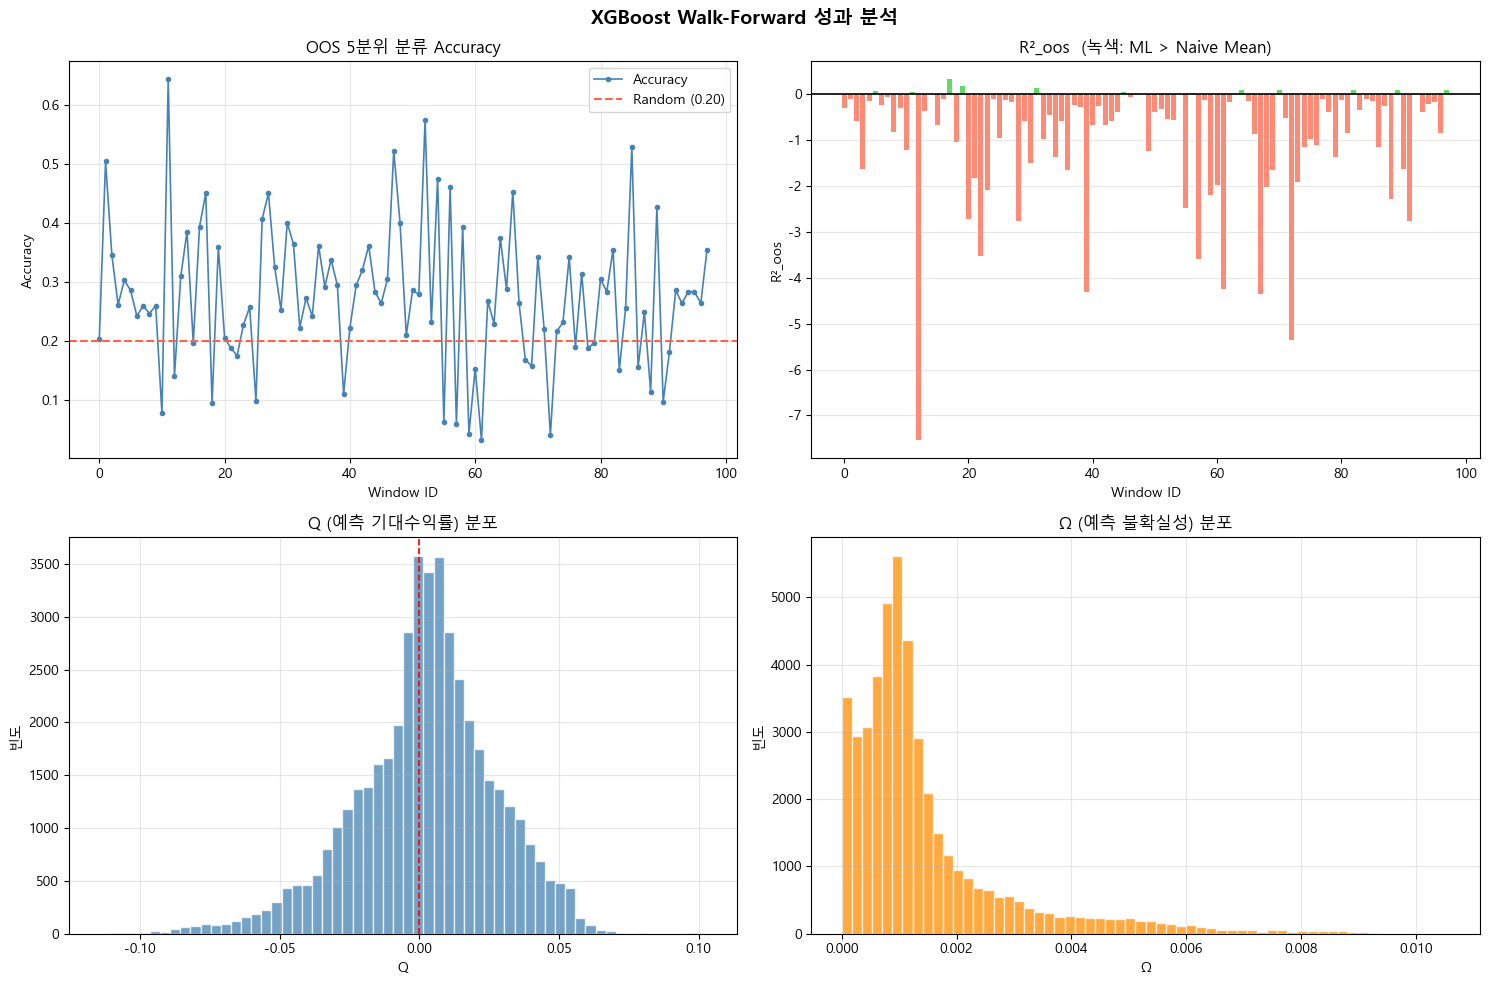

저장: outputs\step3\xgb_walkforward_performance.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("XGBoost Walk-Forward 성과 분석", fontsize=14, fontweight="bold")

# (1) OOS Accuracy by Window
ax = axes[0, 0]
ax.plot(stats_df["window_id"], stats_df["oos_accuracy"],
        marker="o", ms=3, lw=1.2, color="steelblue", label="Accuracy")
ax.axhline(1 / N_CLASSES, color="tomato", ls="--", lw=1.5,
           label=f"Random ({1/N_CLASSES:.2f})")
ax.set_title("OOS 5분위 분류 Accuracy"); ax.set_xlabel("Window ID")
ax.set_ylabel("Accuracy"); ax.legend(); ax.grid(alpha=0.3)

# (2) R²_oos by Window
ax = axes[0, 1]
colors_bar = ["limegreen" if v > 0 else "tomato"
               for v in stats_df["oos_r2"].fillna(0)]
ax.bar(stats_df["window_id"], stats_df["oos_r2"].fillna(0),
       color=colors_bar, alpha=0.75)
ax.axhline(0, color="black", lw=1.2)
ax.set_title("R²_oos  (녹색: ML > Naive Mean)"); ax.set_xlabel("Window ID")
ax.set_ylabel("R²_oos"); ax.grid(alpha=0.3, axis="y")

# (3) Q 분포
ax = axes[1, 0]
ax.hist(results_df["Q"], bins=60, color="steelblue", alpha=0.75, edgecolor="white")
ax.axvline(0, color="red", ls="--", lw=1.2)
ax.set_title("Q (예측 기대수익률) 분포")
ax.set_xlabel("Q"); ax.set_ylabel("빈도"); ax.grid(alpha=0.3)

# (4) Ω 분포
ax = axes[1, 1]
ax.hist(results_df["Omega"], bins=60, color="darkorange", alpha=0.75, edgecolor="white")
ax.set_title("Ω (예측 불확실성) 분포")
ax.set_xlabel("Ω"); ax.set_ylabel("빈도"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgb_walkforward_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {OUTPUT_DIR / 'xgb_walkforward_performance.png'}")

## 11. Q 히트맵 (ETF × 날짜)

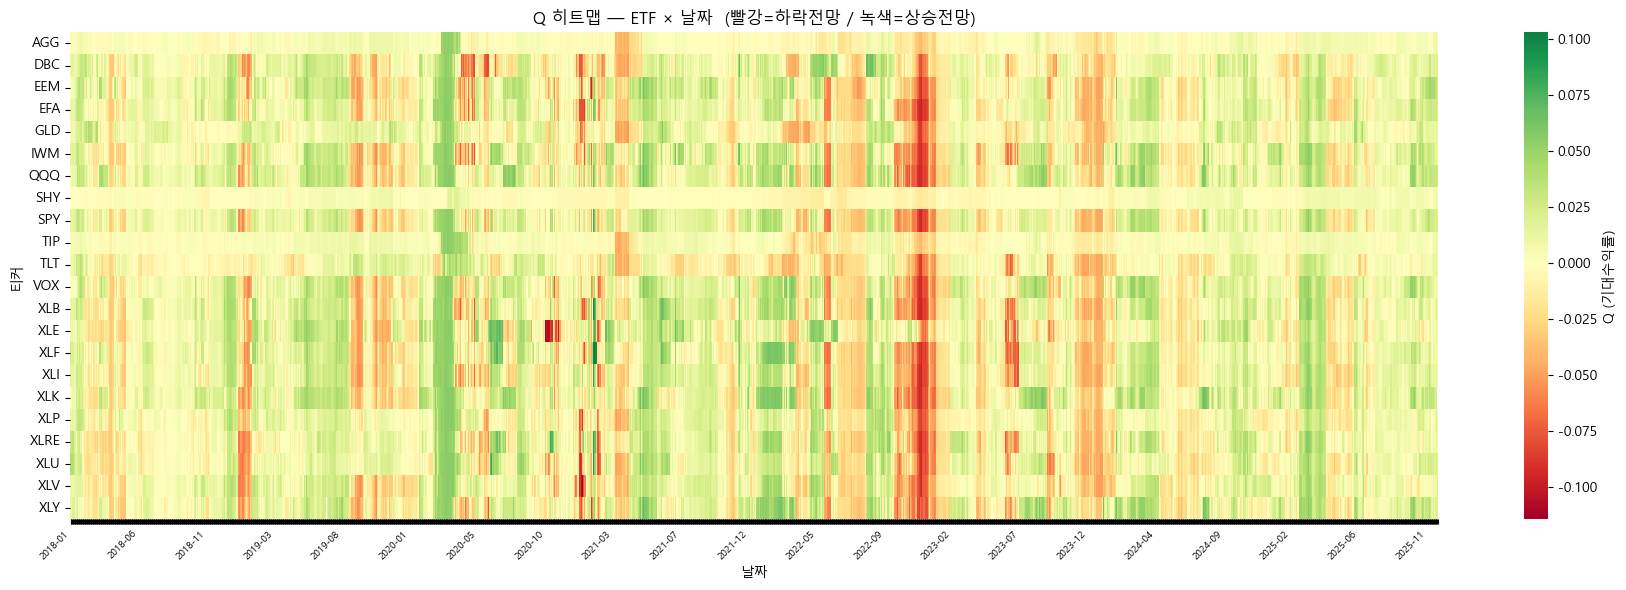

In [14]:
q_pivot = results_df["Q"].unstack("ticker")

n_hm = len(q_pivot)
step = max(1, n_hm // 20)
xlabels = [str(d)[:7] if i % step == 0 else ""
           for i, d in enumerate(q_pivot.index)]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(q_pivot.T, cmap="RdYlGn", center=0, ax=ax,
            xticklabels=xlabels, yticklabels=True,
            cbar_kws={"label": "Q (기대수익률)"})
ax.set_title("Q 히트맵 — ETF × 날짜  (빨강=하락전망 / 녹색=상승전망)", fontsize=12)
ax.set_xlabel("날짜"); ax.set_ylabel("티커")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgb_Q_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

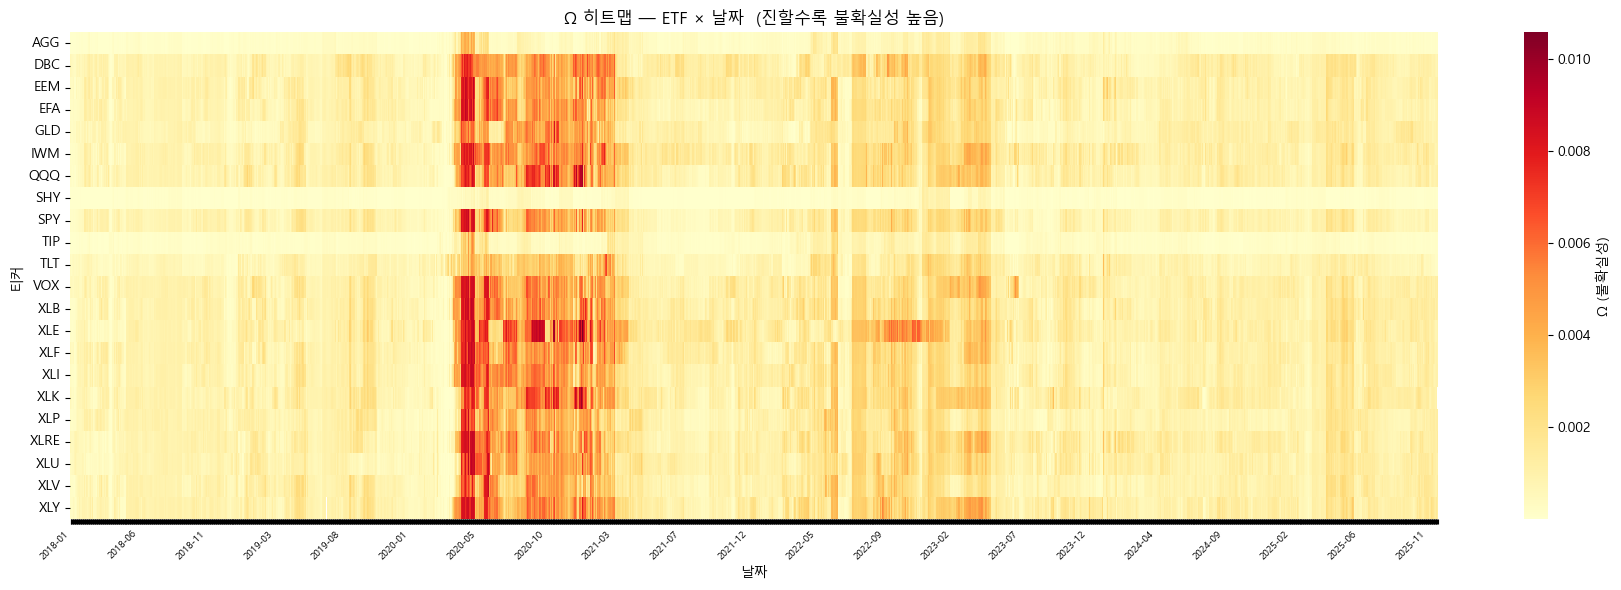

In [15]:
omega_pivot = results_df["Omega"].unstack("ticker")

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(omega_pivot.T, cmap="YlOrRd", ax=ax,
            xticklabels=xlabels, yticklabels=True,
            cbar_kws={"label": "Ω (불확실성)"})
ax.set_title("Ω 히트맵 — ETF × 날짜  (진할수록 불확실성 높음)", fontsize=12)
ax.set_xlabel("날짜"); ax.set_ylabel("티커")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgb_Omega_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. 피처 중요도 (마지막 윈도우 기준)

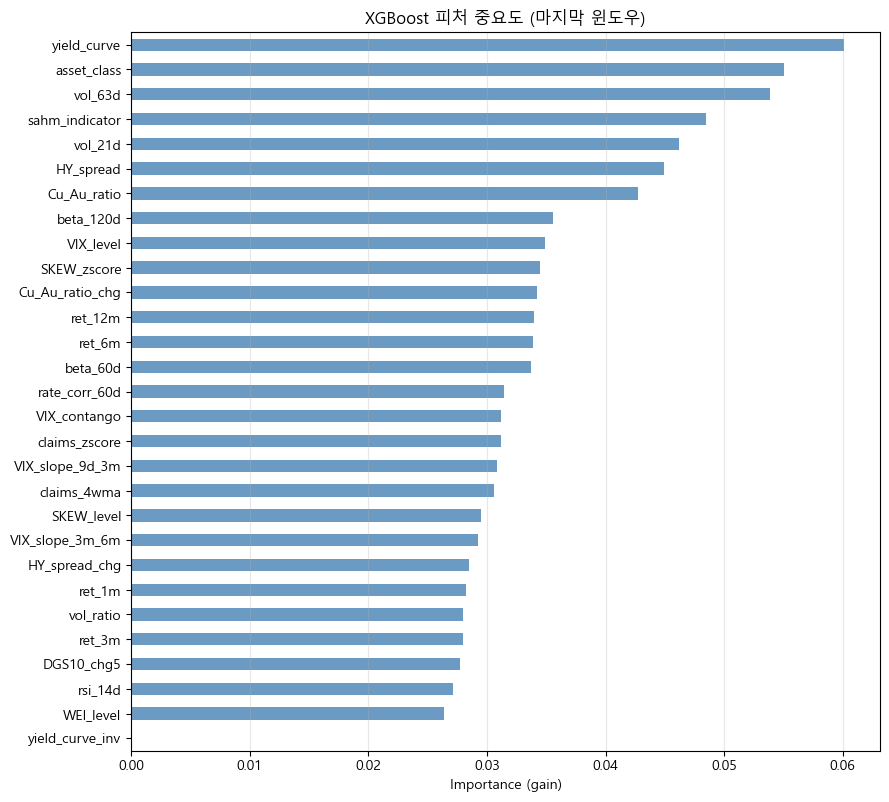


[상위 10 피처]
yield_curve       0.060140
asset_class       0.055077
vol_63d           0.053870
sahm_indicator    0.048446
vol_21d           0.046184
HY_spread         0.044956
Cu_Au_ratio       0.042731
beta_120d         0.035577
VIX_level         0.034910
SKEW_zscore       0.034432


In [16]:
if final_model is not None:
    feat_names = list(final_model.feature_names_in_)
    importance = (pd.Series(final_model.feature_importances_, index=feat_names)
                  .sort_values(ascending=True))

    fig, ax = plt.subplots(figsize=(9, max(6, len(feat_names) * 0.28)))
    importance.plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
    ax.set_title(f"XGBoost 피처 중요도 (마지막 윈도우)", fontsize=12)
    ax.set_xlabel("Importance (gain)"); ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "xgb_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\n[상위 10 피처]")
    print(importance.sort_values(ascending=False).head(10).to_string())

## 13. BL 입력용 Q, Ω 최종 저장

`Step 3-2 Black-Litterman` 노트북에서 바로 사용할 수 있도록
**(date × ticker)** 피벗 형태로 저장한다.


In [17]:
Q_bl     = results_df["Q"].unstack("ticker")
Omega_bl = results_df["Omega"].unstack("ticker")

Q_bl.to_parquet(OUTPUT_DIR / "Q_xgb.parquet")
Omega_bl.to_parquet(OUTPUT_DIR / "Omega_xgb.parquet")

print("=" * 50)
print("✅ BL 입력 파일 저장 완료")
print(f"  Q_xgb.parquet     shape: {Q_bl.shape}")
print(f"  Omega_xgb.parquet shape: {Omega_bl.shape}")
print(f"  저장 위치: {OUTPUT_DIR.resolve()}")
print("\n[Q 마지막 5 날짜 샘플]")
Q_bl.tail()

✅ BL 입력 파일 저장 완료
  Q_xgb.parquet     shape: (2058, 22)
  Omega_xgb.parquet shape: (2058, 22)
  저장 위치: C:\workspace\camp\project\finance_project\서윤범\outputs\step3

[Q 마지막 5 날짜 샘플]


ticker,AGG,DBC,EEM,EFA,GLD,IWM,QQQ,SHY,SPY,TIP,...,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
date,,,,,,,,,,,,,,,,,,,,,
2025-12-04,0.009688,0.019084,0.043698,0.024091,0.013115,0.022413,0.029031,0.008118,0.022710,0.009391,...,0.005724,0.008249,0.011427,0.010984,0.028516,0.011260,0.006475,0.022858,0.009231,0.014690
2025-12-05,0.009898,0.017031,0.036975,0.024183,0.009606,0.013981,0.029243,0.008357,0.022668,0.009429,...,0.010851,0.006822,0.005596,0.011616,0.023559,0.012883,0.005311,0.019793,0.008282,0.022227
2025-12-08,0.009249,0.021213,0.035695,0.028488,0.013153,0.014552,0.031680,0.008300,0.022475,0.009093,...,0.019840,0.013095,0.009033,0.015069,0.022384,0.017775,0.016845,0.022367,0.012792,0.020886
2025-12-09,0.008330,0.024379,0.029792,0.030011,0.014776,0.014776,0.033476,0.008022,0.023565,0.008654,...,0.022772,0.012781,0.013042,0.015014,0.025213,0.013460,0.014266,0.025383,0.024903,0.023879
2025-12-10,0.007606,0.020871,0.022091,0.023465,0.013947,0.013316,0.027553,0.007171,0.019119,0.007157,...,0.007163,0.007236,0.004120,0.007008,NaN,0.008718,0.005792,0.019079,0.018799,0.018347


In [18]:
Omega_bl.tail()

ticker,AGG,DBC,EEM,EFA,GLD,IWM,QQQ,SHY,SPY,TIP,...,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
date,,,,,,,,,,,,,,,,,,,,,
2025-12-04,0.000168,0.000973,0.000948,0.000651,0.000964,0.001043,0.000869,0.000146,0.000581,0.000193,...,0.001260,0.001058,0.001002,0.000795,0.001065,0.001223,0.001334,0.001300,0.001146,0.001511
2025-12-05,0.000169,0.000844,0.001078,0.000814,0.000898,0.000779,0.000958,0.000132,0.000677,0.000177,...,0.001077,0.000764,0.000877,0.000874,0.000987,0.001133,0.001193,0.001184,0.001044,0.001332
2025-12-08,0.000161,0.000730,0.001062,0.000865,0.001012,0.000834,0.001065,0.000101,0.000628,0.000167,...,0.001294,0.000763,0.000996,0.001002,0.001065,0.001245,0.001133,0.001019,0.001046,0.001652
2025-12-09,0.000163,0.000829,0.000957,0.000859,0.000915,0.000865,0.001098,0.000106,0.000675,0.000172,...,0.001295,0.000864,0.000919,0.000823,0.001184,0.001422,0.001385,0.001045,0.001336,0.001745
2025-12-10,0.000153,0.000906,0.001187,0.000997,0.000877,0.000881,0.001208,0.000107,0.000683,0.000145,...,0.001165,0.000922,0.000935,0.001004,NaN,0.001327,0.001477,0.001107,0.001376,0.001356


## 14. 다음 단계

| 단계 | 작업 | 파일 |
|------|------|------|
| Step 3-1 (B) | Random Forest → Q_rf, Ω_rf | `Step3_RF_WalkForward.ipynb` |
| Step 3-1 (C) | LLM Agent → Q_llm, Ω_llm | `Step3_LLM_Agent.ipynb` |
| Step 3-2 | 모델별 성과 비교 + Diebold-Mariano 검정 → 최적 Q, Ω 선택 | `Step3_Model_Selection.ipynb` |
| Step 3-3 | Black-Litterman → μ_BL, Σ_BL | `Step3_BlackLitterman.ipynb` |
| Step 3-4 | MVO (γ별) → 성향별 최적 비중 w* | `Step3_MVO.ipynb` |

---

> **모델 선택 기준 (Step 3-2)**
> RF / XGBoost / TabPFN 각각의 OOS Accuracy, R²_oos, Sharpe(τ* 그리드서치)를
> 독립적으로 비교한 뒤, 가장 우수한 단일 모델의 Q, Ω를 BL에 투입한다.
> (무조건 앙상블 시 신호 상쇄 → 시장 추종으로 수렴 위험)
